In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import ast
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import pipeline
import torch
from datasets import Dataset
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [2]:
conn = sqlite3.connect(r"C:\Users\USER\Documents\MY PORTFOLIO\google-reviews-scraper-pro\reviews.db")

In [3]:
df = pd.read_sql_query(
    """
    select * from reviews
    where place_id != '0x103b921776d4cd3f:0'
    """, conn)

In [4]:
df

,review_id,place_id,author,rating,review_text,review_date,raw_date,likes,user_images,s3_images,...,owner_responses,created_date,last_modified,last_seen_session,last_changed_session,is_deleted,content_hash,engagement_hash,row_version,sub_ratings
0,Ci9DQUlRQUNvZENodHljRjlvT2pRd2JGSjRSMU0yWmtkTF...,0x103b92134bd53de7:0,Alexandre Branco,0.0,"{""en"": ""Staff is the best of the Hotel, nice, ...",2026-06-16T08:20:02+00:00,a week ago on\nGoogle,0,[],None,...,{},2026-06-23T08:20:02.370804+00:00,2026-06-23T08:20:02.370804+00:00,7,6,0,f3df668e5db12491a52e63aabdc420f88d9e9cf97aca5b...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
1,Ci9DQUlRQUNvZENodHljRjlvT25rMWNsQldYekJpYmkxd0...,0x103b92134bd53de7:0,adeyinka ryan,0.0,"{""en"": ""It was a very short trip but very memo...",2026-05-24T08:20:02+00:00,a month ago on\nGoogle,0,[],None,...,"{""en"": {""text"": ""Dear Adeyinka,\n\nThank you f...",2026-06-23T08:20:02.926669+00:00,2026-06-23T08:20:02.926669+00:00,7,6,0,5bf2409fcbbe799c75202f69d4836cbcf66045854d54cb...,3d65d12121c7e79df9da9649c4c50978f3303265c727ed...,1,{}
2,Ci9DQUlRQUNvZENodHljRjlvT2xCMlRHTjBRMGhrUjFaTG...,0x103b92134bd53de7:0,Abisola Abibat,0.0,"{""en"": ""Had a really pleasant stay recently. T...",2026-05-24T08:20:03+00:00,a month ago on\nGoogle,0,[],None,...,{},2026-06-23T08:20:03.377755+00:00,2026-06-23T08:20:03.377755+00:00,7,6,0,04ef5321fd1d8669be3cc6e3e73c3fde9eafa4401ee136...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
3,Ci9DQUlRQUNvZENodHljRjlvT25sU1FrWnNaMjQ1UWpWR2...,0x103b92134bd53de7:0,summy sas,0.0,"{""en"": ""Nice location with brilliant spa servi...",2026-06-09T08:20:03+00:00,2 weeks ago on\nGoogle,0,[],None,...,{},2026-06-23T08:20:03.771880+00:00,2026-06-23T08:20:03.771880+00:00,7,6,0,dfb776bb512e996446d2d6191a317b93537803f81300ac...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
4,Ci9DQUlRQUNvZENodHljRjlvT2tGaVoxRmthRTlHY1haVF...,0x103b92134bd53de7:0,Rebecca,0.0,"{""en"": ""I had a pleasant stay at the Radisson ...",2026-06-02T08:20:03+00:00,3 weeks ago on\nGoogle,0,[],None,...,{},2026-06-23T08:20:04.184101+00:00,2026-06-23T08:20:04.184101+00:00,7,6,0,0dc11aa79899901979ccc7b6a5f0ea8691f222d9f1f82f...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,ChZDSUhNMG9nS0VJQ0FnSURBek5qYmVnEAE,0x103b92134bd53de7:0,Sandy Costagliola,0.0,"{""en"": ""The staff are friendly, the food delic...",2017-06-25T12:37:26+00:00,9 years ago on\nGoogle,0,"[""https://lh3.googleusercontent.com/grass-cs/A...",None,...,{},2026-06-23T12:37:26.726750+00:00,2026-06-23T12:37:26.726750+00:00,7,7,0,841ccd27f6d202fe744cf4412d034612cd9454774b4dd8...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
1236,ChdDSUhNMG9nS0VJQ0FnTUN3NTVyRDlRRRAB,0x103b92134bd53de7:0,Elizabeth Mwangi,0.0,"{""en"": ""Beautiful hotel situated in the middle...",2025-06-23T12:37:28+00:00,a year ago on\nGoogle,0,[],None,...,"{""en"": {""text"": ""Dear Ms. Elizabeth,\n\nThank ...",2026-06-23T12:37:28.345758+00:00,2026-06-23T12:37:28.345758+00:00,7,7,0,bafe07a7f7e4d765ef608d5abf8bd957da56a807cab870...,ec86e2940c4078be930425ba7f6033857d8877e57cabbb...,1,{}
1237,ChZDSUhNMG9nS0VJQ0FnSURCb0lxYkN3EAE,0x103b92134bd53de7:0,Adegbola Adebayo,0.0,"{""en"": ""Had a nice staycation over the Christm...",2023-06-24T12:37:29+00:00,3 years ago on\nGoogle,1,"[""https://lh3.googleusercontent.com/grass-cs/A...",None,...,"{""en"": {""text"": ""Dear Mr. Adebayo,\nThank you ...",2026-06-23T12:37:29.854605+00:00,2026-06-23T12:37:29.854605+00:00,7,7,0,4bac9549d08c0174e7f5abd6433985c180b2c969eadb43...,df2e4c66b8b70355d5b090d84f66844ce3e33b4da8b6cf...,1,{}
1238,ChdDSUhNMG9nS0VJQ0FnSURWdnUtRW5RRRAB,0x103b92134bd53de7:0,Pinorich Hotel,0.0,"{""en"": ""Excellent location in central lagos ne...",2024-06-23T12:37:32+00:00,2 years ago on\nGoogle,0,"[""https://lh3.googleusercontent.com/grass-cs/A...",None,...,"{""en"": {""text"": ""Dear Pinorich,\n\nThank you f...",2026-06-23T12:37

In [5]:
df["review_text"] = (
    df["review_text"]
    .apply(ast.literal_eval)
    .apply(lambda x: x.get("en"))
)

In [6]:
df.columns

Index(['review_id', 'place_id', 'author', 'rating', 'review_text',
       'review_date', 'raw_date', 'likes', 'user_images', 's3_images',
       'profile_url', 'profile_picture', 's3_profile_picture',
       'owner_responses', 'created_date', 'last_modified', 'last_seen_session',
       'last_changed_session', 'is_deleted', 'content_hash', 'engagement_hash',
       'row_version', 'sub_ratings'],
      dtype='object')

In [7]:
# Needed data for analyses

new_df = df.filter(["author", "rating", "review_text", "review_date", "likes"])

In [8]:
new_df.isna().sum()

author         0
rating         0
review_text    0
review_date    0
likes          0
dtype: int64

In [9]:
# Inspect text
new_df["review_text"].to_list()

['Staff is the best of the Hotel, nice, professional and always willing to help. Rooms are good, but can be better. Windows do not lock, which in turn makes it very loud inside the room. Mattress is very old. The gym was the best due to the staff which I could have as PT every day! Outstanding on that!',
 'It was a very short trip but very memorable, a home away from home.\nI loved the ambience and decor.\nFront desk was so impressive especially a staff of yours (Babatunde), had good etiquette and was professional about his job, attending to us timely.\nCustomer service was impressive and as so the quality of care we received.\nThe room was beautiful and large.\nThe food was delicious with a varierty that almost threw any caution I had out the wind! I really enjoyed anything I ate.\nThe security was great. No one could come up to our room without thorough check\nI totally enjoyed my stay. I definitely will visit again and highly recommend.',
 'Had a really pleasant stay recently. The r

In [10]:
# Quick text clean

new_df["review_text"] = (
    new_df["review_text"]
    .str.strip()
    .str.replace("\\n", " ", regex=False)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

In [11]:
# check ratings and likes

print("Existing Unique Ratings: ", new_df["rating"].value_counts())
print("=" * 50)
print("Existing Unique Likes: ", new_df["likes"].value_counts())

Existing Unique Ratings:  rating
0.0    1240
Name: count, dtype: int64
Existing Unique Likes:  likes
0    988
1    194
2     39
3     10
4      4
6      2
7      2
5      1
Name: count, dtype: int64


In [12]:
# Drop ratings since its irrelevant

new_df.drop("rating", axis=1, inplace=True)

In [13]:
# datetime handling

def datetime_cleaning(new_df):

    new_df["review_date"] = pd.to_datetime(new_df["review_date"])
    
    # Extract day, month, year month-year
    
    new_df["day"] = new_df["review_date"].dt.day_name()
    new_df["month"] = new_df["review_date"].dt.month_name()
    new_df["year"] = new_df["review_date"].dt.year
    
    
    # Lets get timing reviews are dropped
    # need hours
    new_df["hour"] = new_df["review_date"].dt.hour

    def hour_conv(hour):
        # morning
        if hour < 12:
            return "morning"
        elif hour < 17:
            return "afternoon"
        else:
            return "night"

    new_df["time"] = new_df["hour"].apply(hour_conv)

    return new_df

In [14]:
new_df = datetime_cleaning(new_df)

In [15]:
# Drop datetime column

new_df.drop("review_date", axis=1, inplace=True)

In [16]:
# Create month_year column

new_df["month_year"] = new_df.apply(lambda x: f"{x['month']}_{x['year']}", axis=1)

In [17]:
# Radisson started operation in 2018 and investigating reviews before 2021

timing = new_df.sort_values(ascending=False, by="year")
time = timing[timing["year"] < 2018]
time.review_text.to_list()

['The staff are friendly, the food delicious, the cocktails strong and the aircon in the room was so cold and the bed so comfy it was like beeing back home in the winter!!! lol',
 'Exquisite, impressive. Good architectural use of space, especially the loft rooms. Beautiful and homely environment. Highly recommended for business and private stay.',
 'i was here for rele Art Exhibition, was a great experience. Awesome ambience, the pool and lobby area is fantastic/luxurious hotel so staying here is not cheap. prices can range from 70,000 to 100,000 Naira per night.',
 'It was another heaven on earth, visited today, the staffs were amazing, the facility is incredible and overall the buffet is wow, I really love it, also a beautiful building, the best hotel in Nigeria I have ever seen and visited, I will keep coming.',
 'Arguably the best hotel in Nigeria. Nice scenery, the ambience is awesome and the staff....the best of the experience. You should try a night here and I promise you would 

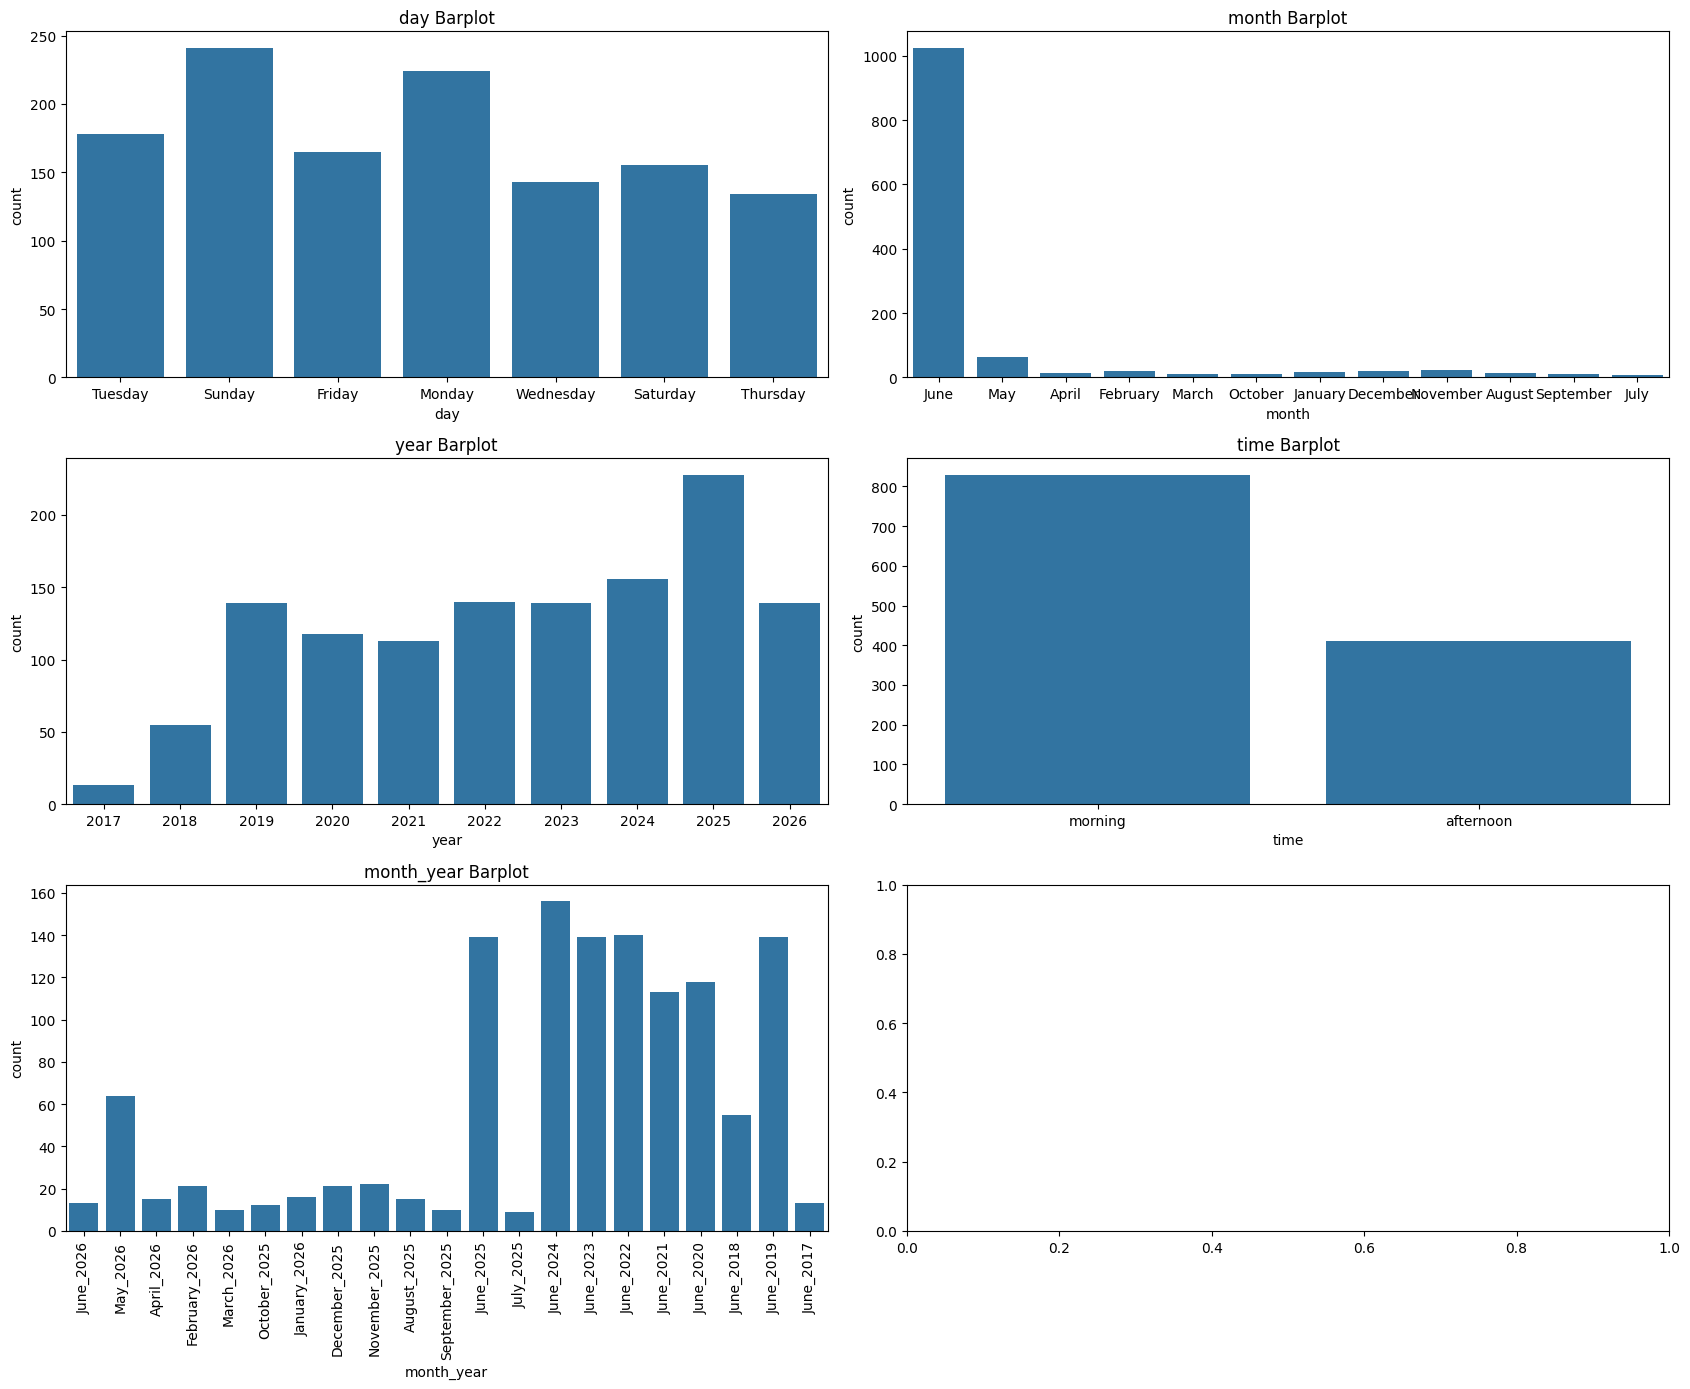

In [18]:
# Lets see the frequency at different day, month, year and time reviews are dropped the most

fig, axes = plt.subplots(3, 2, figsize=(17, 14))

cols = ["day", "month", "year", "time", "month_year"]

temp_df = new_df[cols]

for i, col in enumerate(temp_df.columns):

    row = i//2
    col_ind = i%2

    sns.countplot(x=temp_df[col], ax=axes[row, col_ind])
    axes[row,col_ind].set_title(f"{col} Barplot")
    if col == "month_year":
        axes[row, col_ind].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("day_rad.png")
plt.show()

In [19]:
# Data timing validation

for i in temp_df.columns:
    print(f"Counts of {i} Events: {temp_df[i].value_counts()}")
    print("==" * 50)

Counts of day Events: day
Sunday       241
Monday       224
Tuesday      178
Friday       165
Saturday     155
Wednesday    143
Thursday     134
Name: count, dtype: int64
Counts of month Events: month
June         1025
May            64
November       22
February       21
December       21
January        16
April          15
August         15
October        12
March          10
September      10
July            9
Name: count, dtype: int64
Counts of year Events: year
2025    228
2024    156
2022    140
2026    139
2023    139
2019    139
2020    118
2021    113
2018     55
2017     13
Name: count, dtype: int64
Counts of time Events: time
morning      830
afternoon    410
Name: count, dtype: int64
Counts of month_year Events: month_year
June_2024         156
June_2022         140
June_2025         139
June_2023         139
June_2019         139
June_2020         118
June_2021         113
May_2026           64
June_2018          55
November_2025      22
December_2025      21
February_2026

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


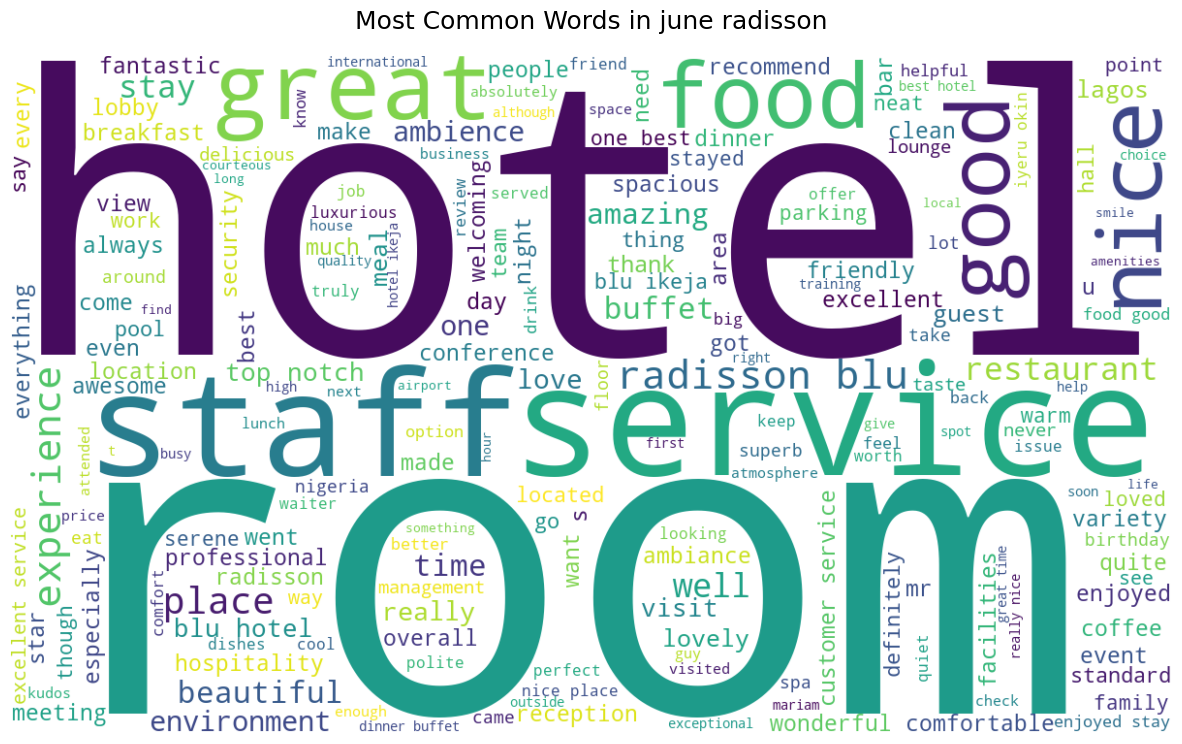

In [20]:
# What happens in june?
june = new_df[(new_df["month"] == "June") & (new_df["year"].isin([2022, 2023, 2024, 2025]))]


# What are they saying?
#clean stopwords
nltk.download("stopwords")

## put to a string
june_words = " ".join(june["review_text"].astype(str)).lower()

## stopwords unique
stop_words = set(stopwords.words("english"))

june_text = " ".join(word for word in june_words.split() if word not in stop_words)

# Word cloud
# Generate wordcloud

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(june_text)


plt.figure(figsize=(15, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in june radisson', 
          fontsize=18, pad=20)
plt.show()

In [21]:
# Lets look at each review and bring out reviews were words likeevent or meetings was mentioned to test our hypothesis

events = [
    review
    for review in june["review_text"]
    if "event" in review.lower() or "meeting" in review.lower()
]
events

['April 24th to 30th 2025. Had a comfortable and relaxed stay. Courteous staff, good place for Business meetings, lounge area on 1st floor is quiet and cozy. Special thanks to Mr. Ayub , he had taken good care of our business meetings.',
 'I booked one of the halls for my little event on Thursday 12th of June, it was a very terrible and bad experience. We paid for buffet food for 60 guests, the food we got was not enough for 20 guests ordinarily talk more of buffet. It was really bad. A guy called Wilson was in charge and we kept pleading with him to help sort things out as majority of our guests hadn’t eaten. He kept insisting we had to pay more. A buffet is meant to be served in surplus but this is the worse I have ever seen in my life, it was way too short. We the host had nothing to eat as our majority of our guests ddnt see food to eat.  Wilson was so rude and wasn’t reasonable. The head of that department and that entire team cheated us so much and I regret ever booking this plac

## Reports for Time Data
**Note: The dataset is 8% of the existing total reviews in google maps**
- Sunday, monday and tuesday are the top days reviews are sent. Maybe weekend customers.
- A large percentage of reviews are sent in the month june. dating from 2017 till 2025, a huge percentage of reviews are sent in june
- 2025 is the year with the highest review
- Most reviews are sent in the morning and non at night
- June activity shows mention of events be review authors but we dont have significant evidence to classify repeated review spike activity in june as event driven

# Handling Text Data

In [22]:
data = new_df["review_text"].astype(str)
all_text = " ".join(data)
all_text = all_text.lower()

In [23]:
# Get stopwords

nltk.download("stopwords")
#get unique english stopwords
stop_words = set(stopwords.words("english"))

# remove stopwords from "all_text"

filtered_text = " ".join(
    word for word in all_text.split()
    if word.lower() not in stop_words
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


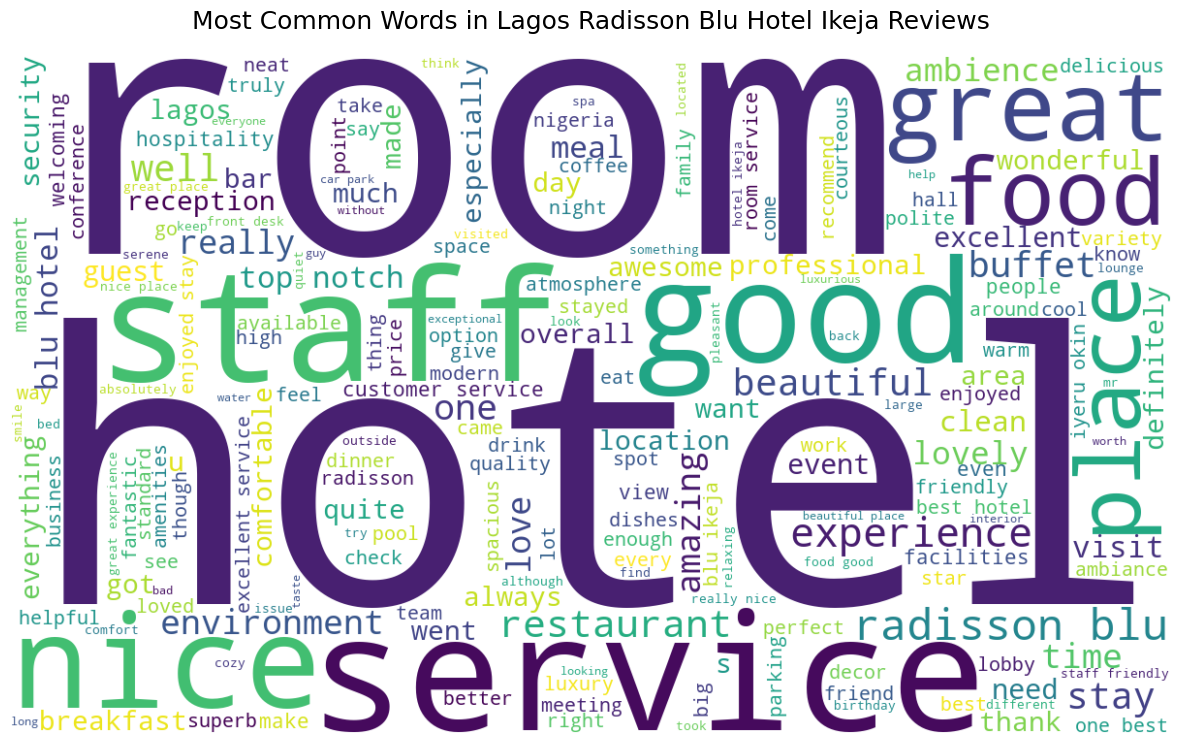

In [24]:
# Generate wordcloud

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(filtered_text)


plt.figure(figsize=(15, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Lagos Radisson Blu Hotel Ikeja Reviews', 
          fontsize=18, pad=20)
plt.savefig("rad_word.png")
plt.show()

## Reports on Most Common Words

- Common words resonates around food, service, room, hotel, staff and some direct positive words

# Sentiment Analyses

In [25]:
sia = SentimentIntensityAnalyzer()
new_df['sentiment'] = new_df['review_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

## Difference in most positive and negative word cloud

In [26]:
# Lets find out common words for negative sentiment

neg_text = " ".join(new_df[new_df["sentiment"] <= 0]["review_text"].astype(str))

stop_words = set(stopwords.words("english"))

# remove stopwords from text
text = " ".join(
    word for word in neg_text.split()
    if word.lower() not in stop_words
)

# Lets find out common words for positive sentiment

pos_text = " ".join(new_df[new_df["sentiment"] > 0]["review_text"].astype(str))

stop_words = set(stopwords.words("english"))

# remove stopwords from text
postext = " ".join(
    word for word in pos_text.split()
    if word.lower() not in stop_words
)

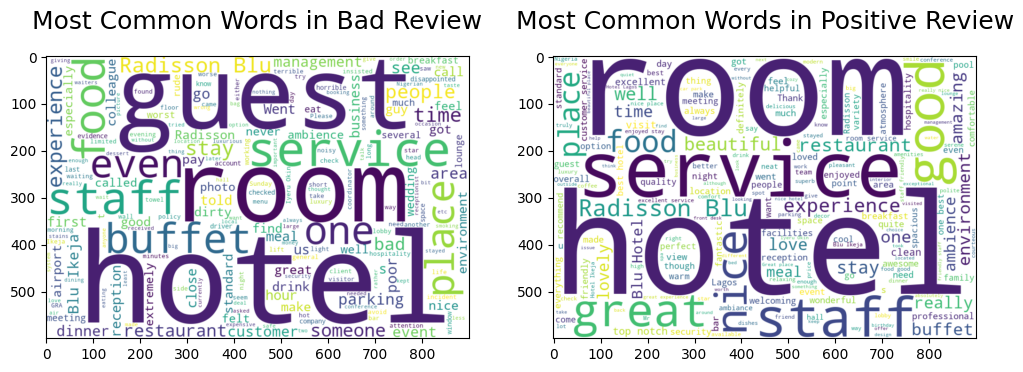

In [56]:
# Most Common words in Negative review

# Negative
wordcloud = WordCloud(
    width=900,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(text)

# Positive
pos_wordcloud = WordCloud(
    width=900,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(postext)

fig, axes = plt.subplots(1, 2, figsize=(12, 9))
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[1].imshow(pos_wordcloud, interpolation='bilinear')
axes[0].set_title('Most Common Words in Bad Review', 
          fontsize=18, pad=20)
axes[1].set_title('Most Common Words in Positive Review', 
          fontsize=18, pad=20)
plt.savefig("neg_pos_rad.png")
plt.show()

## Reports from Word Cloud

**There is consistent large words like room, hotel, staff, service, food and experience**
- Staff: The above shows there is consistent appearance of the word "staff" in both kind of reviews, meaning different kind of people experienced radisson blu staffing in different kind of way
- Food: In the bad review section, food and words related to food like buffet, dinner, breakfast, restaurant, meal are quite consistent given the size of the words. while in the positive side, consistent words related to food are restaurant, buffet, meal and food itself. Food and food related wordings in the bad reviews are quite larger and wore than the ones in positive reviews
- Room & Hotel: room and hotel in general appears larger in positive reviews than negative reviews
- There is also consistent words on the word "service in positive review and negative review, positive review a bit larger
- There is a big mention of the word guest in negative review but non of the word in positive review

**Summary**
- Key things customer talks about are room, service, hotel, staff, food, experience
- Food and food related word tend to be more consistent in negative review than in positive


In [59]:
# Why is guest present in negative?
nega_sent = new_df[new_df["sentiment"] <= 0]["review_text"]

guest = [word for word in nega_sent if "guest" in word.lower()]
guest

['I stayed at Radisson Blu Ikeja from January 7–10, 2026 for my wedding and had an extremely distressing experience.  Despite paying a photography fee, staff repeatedly interrupted our photo sessions and inconsistently enforced “off-limits” areas, while other guests were later allowed to take photos in those same locations.  More concerning was a serious breach of privacy on the morning of my wedding, when a staff member entered my suite without consent while I was undressed, demanding payment. This was humiliating and completely unacceptable.  I reported these incidents in person to hotel management at checkout, yet the hotel itself never formally acknowledged what occurred. Later that day, my husband received a call offering us lunch as a resolution, which felt dismissive given the seriousness of the incident.  I also contacted Radisson Hotel Group head office, where a case was opened and the seriousness acknowledged. However, I have received no meaningful resolution, refund, or time

# Using Zero Shot Classification from HuggingFace

In [28]:
classifier = pipeline(
    "zero-shot-classification", 
    model="facebook/bart-large-mnli",
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [29]:
# Pick the most common words in the word cloud as c;ass

labels = ["Food Related", "Staff Related", "Services Related", "Room Related"]

# Function to classify
def classify(text):
    result = classifier(text, labels, multi_label=False)

    return {
        'class': result['labels'][0],
        'confidence': round(result['scores'][0], 4)
    }

In [30]:
results = new_df['review_text'].apply(classify)

In [31]:
new_df["class"] = [r["class"] for r in results]
new_df["confidence"] = [r["confidence"] for r in results]

In [32]:
def sentiment(text):
    if text > 0:
        return "Positive Review"
    else:
        return "Negative Review"

In [33]:
new_df["Sentiment Class"] = new_df["sentiment"].apply(sentiment)

# Checking most common negative review

In [34]:
neg = new_df[new_df["Sentiment Class"] == "Negative Review"]
pos = new_df[new_df["Sentiment Class"] != "Negative Review"]

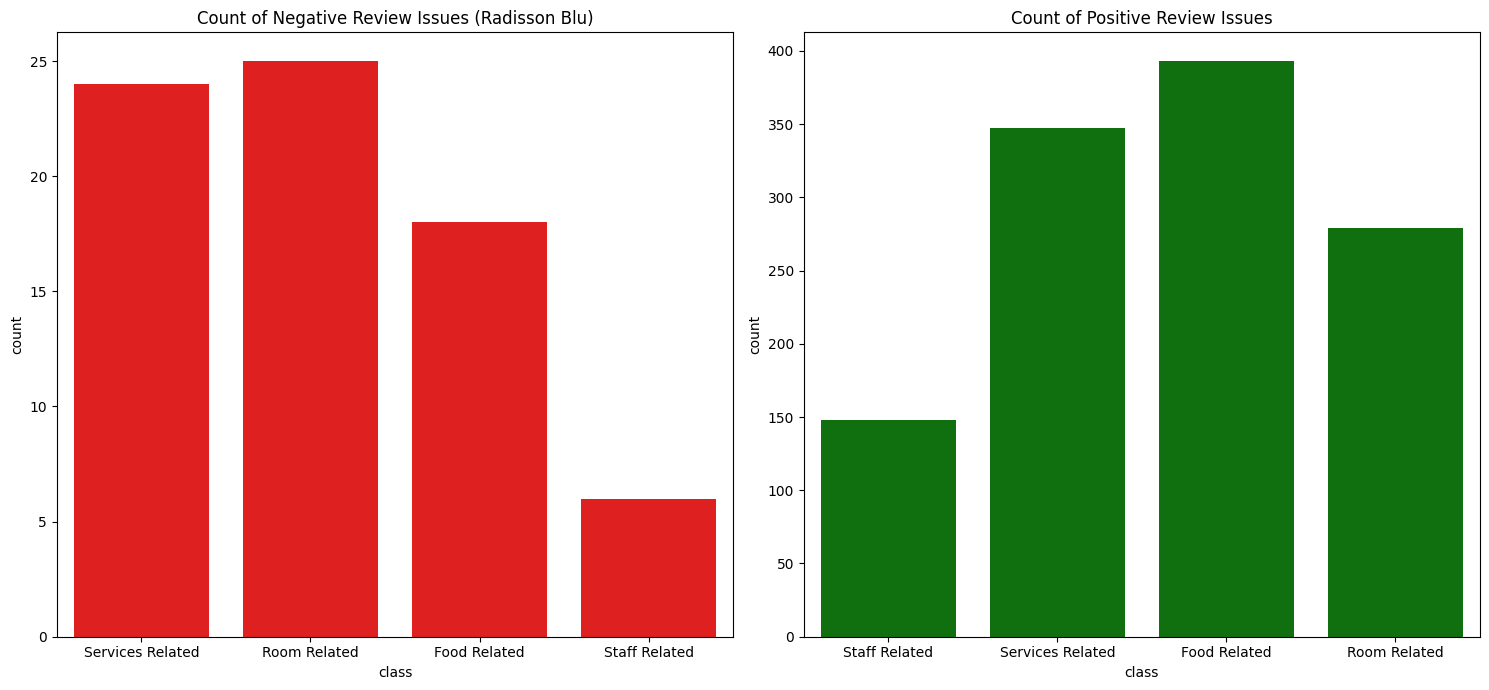

In [62]:
# Countplot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.countplot(data=neg, x="class", color="red", ax=axes[0])
sns.countplot(data=pos, x="class", color="green")
axes[0].set_title("Count of Negative Review Issues (Radisson Blu)")
axes[1].set_title("Count of Positive Review Issues")
plt.tight_layout()
plt.savefig("pos_neg_bar.png")
plt.show()

In [65]:
# I want to see the negative percentage of each class
## create a loop for each class
for clas in neg["class"].unique():
    nega = neg[neg["class"] == clas]
    posi = pos[pos["class"] == clas]

    percentage = len(nega) / (len(nega) + len(posi))

    print(f"{clas}: {percentage:.2f}")
    print("=" * 50)

Services Related: 0.06
Room Related: 0.08
Food Related: 0.04
Staff Related: 0.04


In [63]:
# Why is negative food complaint percentage 3rd?
nega_sent = new_df[new_df["sentiment"] <= 0]["review_text"]

food = [word for word in nega_sent if "food" in word.lower() or "buffet" in word.lower()]
food

["I had dinner at Iyeru Okin-The buffet restaurant in this hotel. It was an exceedingly underwhelming experience.  A discourteous front desk representative, a very lean spread consisting of generally bland meals. Even the fruits somehow managed to be tasteless.  The dining area was oppressively hot and the ambiance very dull.  For a buffet deal that cost ₦40,000 per head, I left the restaurant feeling like I did not get my money's worth.  Oh...As soon as I tasted the meals, I realised why the receptionist insisted on receiving payment before the buffet even started-a policy I found utterly ridiculous, by the way.  The management at Iyeru Okin probably fears that the horrid meals and subpar service will cause many incidents of dine and dash.",
 "Was just here for the food, breakfast buffet isn't that much, and for some reason it's more expensive than Sheraton...and they have way more options...idk, but iffy about the Raddisson",
 'Hotel is shabby. Staff are overwhelmed and seem afraid t

In [38]:
df.to_csv("Radisson_Public_Reviews.csv", index=False)

In [39]:
new_df["Sentiment Class"].value_counts()

Sentiment Class
Positive Review    1167
Negative Review      73
Name: count, dtype: int64

## Lets See The Month Year and day bad reviews were posted the most

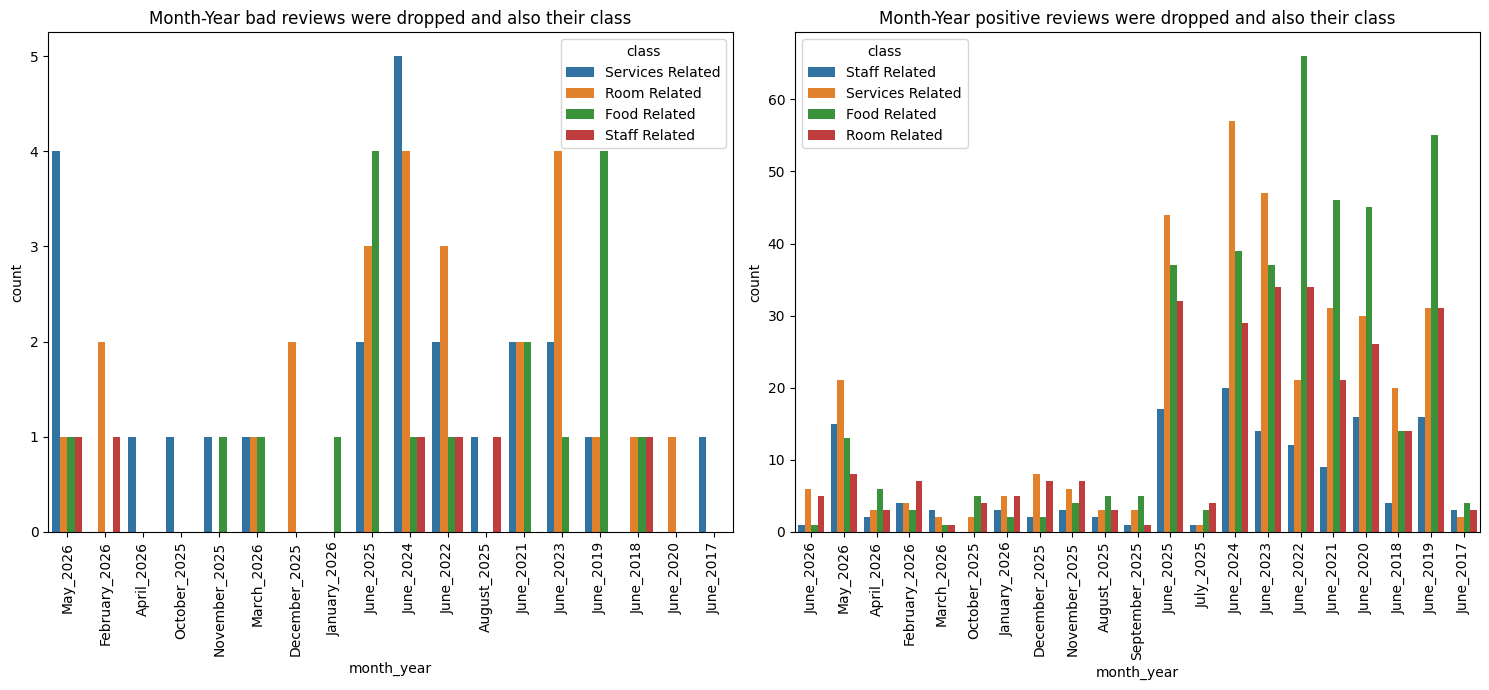

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.countplot(data=neg, x="month_year", hue="class", ax=axes[0])
sns.countplot(data=pos, x="month_year", hue="class", ax=axes[1])
axes[0].tick_params(axis="x", rotation=90)
axes[1].tick_params(axis="x", rotation=90)
axes[0].set_title("Month-Year bad reviews were dropped and also their class")
axes[1].set_title("Month-Year positive reviews were dropped and also their class")
plt.tight_layout()
plt.savefig("month-year.png")
plt.show()

## Reports on Complaints and the Timing
**Month-Year**
- Peak complaint was in june 2024 on service related review
- June 2019, 2023, 2021, 2022, 2024, and 2025 have the highest complaints and majorly in room, food and service related reviews
- In 2026, there are 3 bad reviews on food, 6 on service related review, 4 on room related review and 2 in staff related review

## Reports on positive reviews and the timing

**Month-Year**
- June 2019, 2020, 2021, 2022, 2023, 2024 and 2025 have the highest number of positive reviews, with food peaking in 2022
- In 2026, may has the highest number of positive reviews with service, staff and food at the top in may and most of the month


# Building predictive models to classify reviews into positive and negative¶

In [42]:
# i need to get it into huggingface dataset
data = new_df[["review_text", "Sentiment Class"]]

In [43]:
data["Sentiment Class"].value_counts()

Sentiment Class
Positive Review    1167
Negative Review      73
Name: count, dtype: int64

In [44]:
# data needs sampling
# First, let me convert labels to nemeric
data["label"] = data["Sentiment Class"].map({"Positive Review": 1, "Negative Review": 0})
# drop the cat col
data.drop("Sentiment Class", axis=1, inplace=True)

# Split data to X and y
X = data["review_text"].values.reshape(-1, 1)
y= data["label"].values.reshape(-1, 1)

#Before sampling, let me split to avoid overfitting include stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# resample
ros = RandomOverSampler(random_state=42)
X_resample, y_resample = ros.fit_resample(X_train, y_train)

C:\Users\USER\AppData\Local\Temp\ipykernel_1840\2376260983.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["label"] = data["Sentiment Class"].map({"Positive Review": 1, "Negative Review": 0})
C:\Users\USER\AppData\Local\Temp\ipykernel_1840\2376260983.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop("Sentiment Class", axis=1, inplace=True)


In [45]:
# Put both in a pandas dataframe so we can pull into huggingface dataset easily

train_data = pd.DataFrame({"Text": X_resample.flatten(), "label": y_resample})
test_data = pd.DataFrame({"Text": X_test.flatten(), "label": y_test.flatten()})

# Class weight
# Calculate balanced class weights
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_data['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

In [46]:
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

In [47]:
# Tokenization: we use opensourced tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [48]:
# Define tokenizer function
def tokenize(examples):
    return tokenizer(examples["Text"], padding="max_length", truncation=True, max_length=64)

In [49]:
# Lets tokenize our datasets
tokenized_train = train_dataset.map(tokenize, batched=True)
tokenized_test = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1868 [00:00<?, ? examples/s]

Map:   0%|          | 0/248 [00:00<?, ? examples/s]

In [50]:
# Load Pretrained Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [51]:
# Configure Training
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=1)
    results = {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1.compute(predictions=predictions, references=labels, average="binary")["f1"],
        "precision": precision.compute(predictions=predictions, references=labels, average="binary")["precision"],
        "precision_neg": precision.compute(predictions=predictions, references=labels, pos_label=0, average="binary")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, average="binary")["recall"]
    }
    return results

training_args = TrainingArguments(
    output_dir="./radisson_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=1,
    load_best_model_at_end=True,
    report_to="none"
)

In [52]:
# Trying to solve for class imbalance

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

In [53]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Precision Neg,Recall
1,0.000840,0.251381,0.963710,0.980728,0.978632,0.714286,0.982833
2,0.000289,0.298184,0.959677,0.978632,0.974468,0.692308,0.982833
3,0.000096,0.323291,0.963710,0.980728,0.978632,0.714286,0.982833
4,0.000086,0.343258,0.959677,0.978632,0.974468,0.692308,0.982833
5,0.000160,0.345032,0.959677,0.978632,0.974468,0.692308,0.982833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2335, training_loss=0.033440777290258725, metrics={'train_runtime': 1649.4044, 'train_samples_per_second': 5.663, 'train_steps_per_second': 1.416, 'total_flos': 154655687930880.0, 'train_loss': 0.033440777290258725, 'epoch': 5.0})

In [54]:
import shutil
import os


output_dir = "./radisson_sentiment"


if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f" Deleted old model folder: {output_dir}")


model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model successfully saved to: {output_dir}")

 Deleted old model folder: ./radisson_sentiment


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model successfully saved to: ./radisson_sentiment


In [55]:
# Load and test model

fine_tuned_model = AutoModelForSequenceClassification.from_pretrained(output_dir)
updated_tokenizer = AutoTokenizer.from_pretrained(output_dir)

test_reviews = [
    "Radisson blu is much more better than marriot, their food is worth the price",
    "I don't like how they treat their staff at radisson, they should take them as priority also and also the food was bad",
    "Please marriot is better than your nonsense food and the rubbish you guys are doing here in radisson blu"
]

for test in test_reviews:
    inputs = updated_tokenizer(test, return_tensors="pt", padding=True, truncation=True, max_length=64)

    with torch.no_grad():
        outputs = fine_tuned_model(**inputs)

    predicted_id = torch.argmax(outputs.logits, dim=-1).item()
    sentiment = "Positive" if predicted_id == 1 else "Negative"
    confidence = torch.softmax(outputs.logits, dim=-1)[0][predicted_id].item()

    print(test)
    print(sentiment)
    print(confidence)
    print("==" * 50)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Radisson blu is much more better than marriot, their food is worth the price
Positive
0.9995028972625732
I don't like how they treat their staff at radisson, they should take them as priority also and also the food was bad
Negative
0.9821569919586182
Please marriot is better than your nonsense food and the rubbish you guys are doing here in radisson blu
Positive
0.999325156211853
